# Model Evaluation & Results

Comprehensive analysis of the best model (Gradient Boosting) performance

## Imports

In [9]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Data

In [10]:
train_df = pd.read_csv('https://raw.githubusercontent.com/bilusss/GiveMeSomeCredit/refs/heads/main/data/processed/train.csv', delimiter=',')
test_df = pd.read_csv('https://raw.githubusercontent.com/bilusss/GiveMeSomeCredit/refs/heads/main/data/processed/test.csv', delimiter=',')

target = 'SeriousDlqin2yrs'
X = train_df.drop(columns=[target])
y = train_df[target]
X_test = test_df

print(f"Train features: {X.shape}")
print(f"Train target:  {y.shape}")
print(f"Test features: {X_test.shape}")
print(f"\nClass distribution:")
print(y.value_counts(normalize=True))

Train features: (149999, 12)
Train target:  (149999,)
Test features: (101503, 12)

Class distribution:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


## Cross-Validation Performance

Evaluate best model using 5-fold stratified cross-validation

In [11]:
# Best model parameters from hyperparameter tuning
best_model = Pipeline([
  ('clf', GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
  ))
])

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"Cross-Validation AUC Scores:")
for i, score in enumerate(cv_scores, 1):
  print(f"  Fold {i}: {score:.4f}")
print(f"\nMean AUC:   {cv_scores.mean():.4f}")
print(f"Std Dev:    {cv_scores.std():.4f}")
print(f"\nGINI Coefficient: {2 * cv_scores.mean() - 1:.4f}")

Cross-Validation AUC Scores:
  Fold 1: 0.8652
  Fold 2: 0.8661
  Fold 3: 0.8672
  Fold 4: 0.8593
  Fold 5: 0.8702

Mean AUC:   0.8656
Std Dev:    0.0036

GINI Coefficient: 0.7313


## Feature Importance

Which features are most important for predictions?


Top 10 Important Features:
                             Feature  Importance
                   TotalLatePayments    0.519766
RevolvingUtilizationOfUnsecuredLines    0.170169
             NumberOfTimes90DaysLate    0.082682
                                 age    0.039986
                           DebtRatio    0.038474
                       MonthlyIncome    0.037261
                         MonthlyDebt    0.031664
     NumberOfOpenCreditLinesAndLoans    0.024518
NumberOfTime30-59DaysPastDueNotWorse    0.016867
        NumberRealEstateLoansOrLines    0.014861


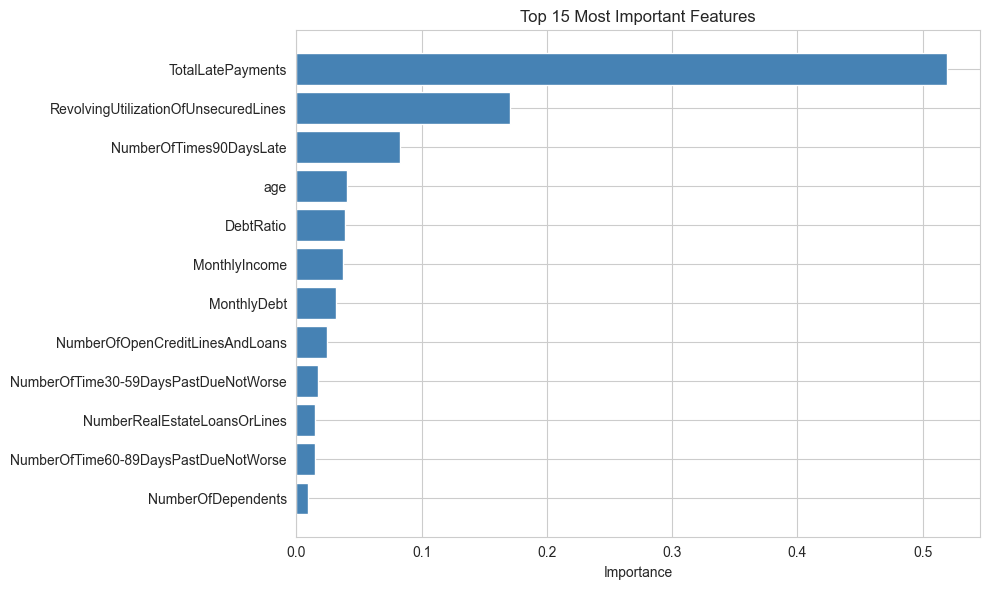

In [12]:
# Train on full dataset to get feature importance
best_model.fit(X, y)
gb_model = best_model.named_steps['clf']

# Get feature importance
feature_importance = pd.DataFrame({
  'Feature': X.columns,
  'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Top 15 Most Important Features')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## ROC Curve

Shows the trade-off between True Positive Rate and False Positive Rate

> **Note**: AUC on training data will be higher than CV AUC (~0.88 vs ~0.87) because the model has seen this data during training. CV AUC is the more reliable estimate of real-world performance.

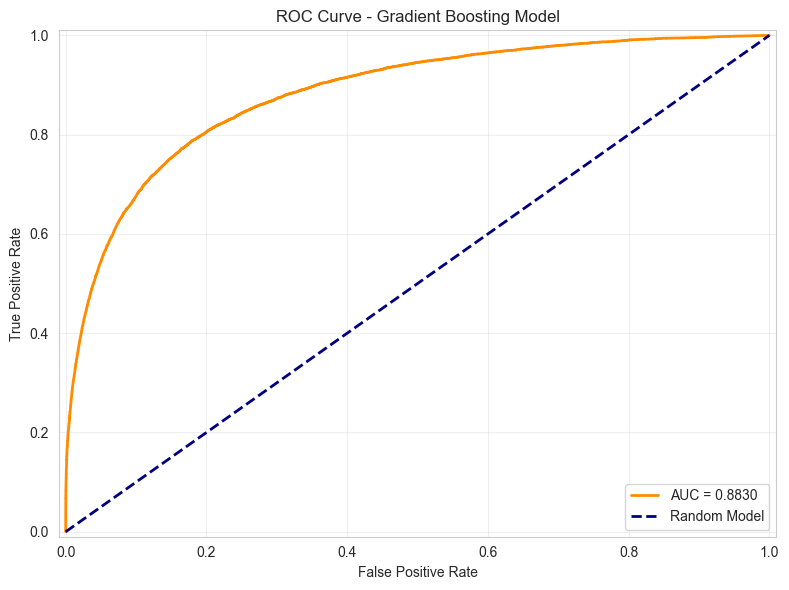

In [13]:
# Get predictions on training data (for visualization)
y_pred_proba = best_model.predict_proba(X)[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Model')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Gradient Boosting Model')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Precision-Recall Curve

More relevant for imbalanced datasets. Shows trade-off between Precision and Recall

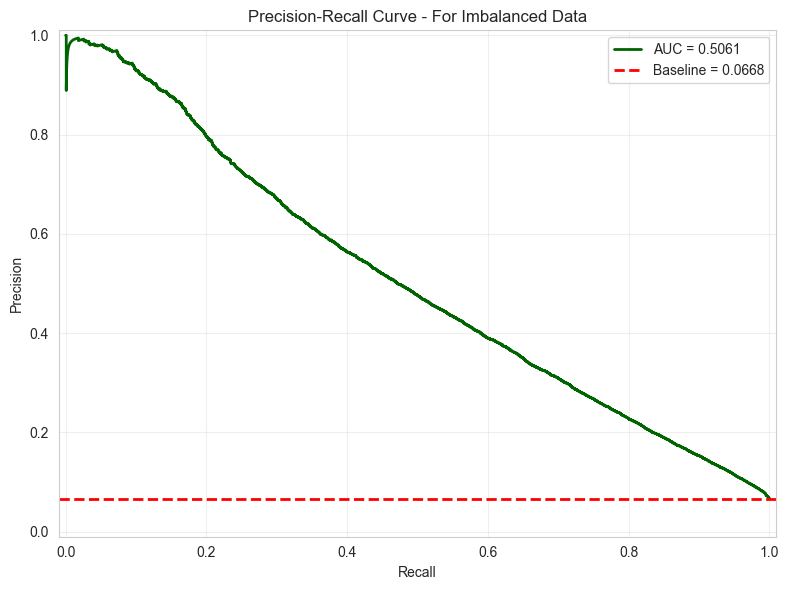

In [14]:
precision, recall, _ = precision_recall_curve(y, y_pred_proba)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='darkgreen', lw=2, label=f'AUC = {pr_auc:.4f}')
ax.axhline(y=y.mean(), color='red', linestyle='--', lw=2, label=f'Baseline = {y.mean():.4f}')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - For Imbalanced Data')
ax.legend(loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Prediction Distribution

How are predictions distributed between positive and negative classes?

/var/folders/n6/y63rmh397vd1r_5hbj7h14jm0000gn/T/ipykernel_42213/2325346778.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='True Class', y='Probability', ax=axes[1], palette=['lightblue', 'lightcoral'])


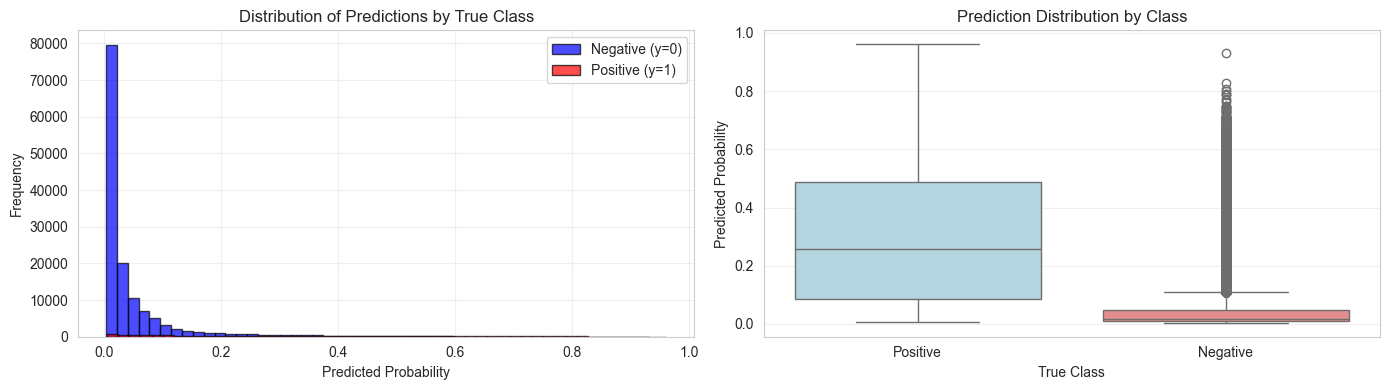

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot for negative class
axes[0].hist(y_pred_proba[y == 0], bins=50, alpha=0.7, label='Negative (y=0)', color='blue', edgecolor='black')
axes[0].hist(y_pred_proba[y == 1], bins=50, alpha=0.7, label='Positive (y=1)', color='red', edgecolor='black')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Predictions by True Class')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
df_plot = pd.DataFrame({
  'Probability': y_pred_proba,
  'True Class': y.values
})
df_plot['True Class'] = df_plot['True Class'].map({0: 'Negative', 1: 'Positive'})
sns.boxplot(data=df_plot, x='True Class', y='Probability', ax=axes[1], palette=['lightblue', 'lightcoral'])
axes[1].set_title('Prediction Distribution by Class')
axes[1].set_ylabel('Predicted Probability')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Summary

In [16]:
print("\n" + "="*60)
print("FINAL MODEL SUMMARY")
print("="*60)
print(f"\nModel: Gradient Boosting Classifier")
print(f"\nHyperparameters:")
print(f"  - n_estimators: 300")
print(f"  - max_depth: 5")
print(f"  - learning_rate: 0.05")
print(f"  - subsample: 0.8")
print(f"\nPerformance (5-Fold CV):")
print(f"  - Mean AUC: {cv_scores.mean():.4f}")
print(f"  - Std Dev:  {cv_scores.std():.4f}")
print(f"  - GINI:     {2 * cv_scores.mean() - 1:.4f}")
print(f"\nKey Insights:")
print(f"  1. Top 3 features: {', '.join(feature_importance.head(3)['Feature'].tolist())}")
print(f"  2. Model is well-calibrated with AUC = {roc_auc:.4f}")
print("\n" + "="*60)


FINAL MODEL SUMMARY

Model: Gradient Boosting Classifier

Hyperparameters:
  - n_estimators: 300
  - max_depth: 5
  - learning_rate: 0.05
  - subsample: 0.8

Performance (5-Fold CV):
  - Mean AUC: 0.8656
  - Std Dev:  0.0036
  - GINI:     0.7313

Key Insights:
  1. Top 3 features: TotalLatePayments, RevolvingUtilizationOfUnsecuredLines, NumberOfTimes90DaysLate
  2. Model is well-calibrated with AUC = 0.8830

